In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
PHYSICAL_PREDICTORS = ["Wd", "We"]   
TARGET_INT = ["Theta", "X", "Y"]       
TARGET = ["DeltaTheta", "DeltaX", "DeltaY"]       
TIME_STEPS = 15
TS = 0.07
TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]

Datasets = []
for title in TITLES:
    df = pd.read_excel("../../../00-Data/SavgolDatasets.xlsx", sheet_name=title)
    Datasets.append(df)



In [2]:
import matplotlib.pyplot as plt

R = 0.0328
L = 0.0615
dt = 0.07

def CinematicModel(Wd, We, theta):
    dtheta_cin = (R/(2*L)) * (Wd - We)
    dx_cin = (R/2) * np.cos(theta) * (Wd + We)
    dy_cin = (R/2) * np.sin(theta) * (Wd + We)
    return [dtheta_cin, dx_cin, dy_cin]

def NumericalIntegration(Dataset, dq):
    
    init_vals = np.array([
        Dataset["Theta"].iloc[0],
        Dataset["X"].iloc[0],
        Dataset["Y"].iloc[0]
    ]) 
    
    theta_cin = init_vals[0] + np.cumsum(dq[0] * dt)
    x_cin     = init_vals[1] + np.cumsum(dq[1] * dt)
    y_cin     = init_vals[2] + np.cumsum(dq[2] * dt)
    return [theta_cin, x_cin, y_cin]
 
def PlotOut(ax, title, target_name, y_true, y_spline, y_cin):

    # 🔹 pega menor tamanho comum
    n = min(len(y_true), len(y_spline), len(y_cin))

    # 🔹 corta tudo igual
    y_true   = y_true[:n]
    y_spline = y_spline[:n]
    y_cin    = y_cin[:n]

    # 🔹 tempo consistente
    time = (np.arange(n).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, label='Amostras Reais')
    ax.plot(time, y_spline, linestyle='--', linewidth=1.5, label='Valores Filtrados')
    ax.plot(time, y_cin, linestyle=':', linewidth=1.5, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)

In [3]:
import pandas as pd
import numpy as np
from itertools import product

df_X_all = pd.read_excel("../X/resultados_comparacao.xlsx", sheet_name=None)
df_Y_all = pd.read_excel("../Y/resultados_comparacao.xlsx", sheet_name=None)

# 🔹 pegar colunas (assume iguais em todos)
sample_dfX = list(df_X_all.values())[0]
sample_dfY = list(df_Y_all.values())[0]

cols_X = [c for c in sample_dfX.columns if "X_pred_" in c or c == "X_ens"]
cols_Y = [c for c in sample_dfY.columns if "Y_pred_" in c or c == "Y_ens"]

results = []

# 🔹 testar TODAS combinações globalmente
for col_x, col_y in product(cols_X, cols_Y):

    erros_all = []

    for title in TITLES:

        dfX = df_X_all[title]
        dfY = df_Y_all[title]

        X_real = dfX["X_real"].values
        Y_real = dfY["Y_real"].values

        X_pred = dfX[col_x].values
        Y_pred = dfY[col_y].values
        
        min_len = min(len(X_real), len(X_pred), len(Y_real), len(Y_pred))

        X_real = X_real[:min_len]
        Y_real = Y_real[:min_len]
        X_pred = X_pred[:min_len]
        Y_pred = Y_pred[:min_len]

        erro = np.sqrt((X_real - X_pred)**2 + (Y_real - Y_pred)**2)
        erros_all.append(np.mean(erro))

    erro_global = np.mean(erros_all)

    results.append({
        "X_model": col_x,
        "Y_model": col_y,
        "erro_global": erro_global
    })

df_rank = pd.DataFrame(results).sort_values("erro_global")

# 🔹 TOP 3
top3 = df_rank.head(3)

print(top3)

# 🔹 salvar
top3.to_excel("top3_combinacoes_gerais.xlsx", index=False)

                                            X_model  \
0  X_pred_model_arch64-32_r0.9_Ld0.7_Lp0.3_seed3227   
5                                             X_ens   
4  X_pred_model_arch64-32_r0.9_Ld0.7_Lp0.3_seed3227   

                                            Y_model  erro_global  
0  Y_pred_model_arch16-8_r0.01_Ld0.7_Lp0.3_seed8792     0.191384  
5  Y_pred_model_arch16-8_r0.01_Ld0.7_Lp0.3_seed8792     0.191384  
4                                             Y_ens     0.193281  


In [4]:
display(top3)

,X_model,Y_model,erro_global
0,X_pred_model_arch64-32_r0.9_Ld0.7_Lp0.3_seed3227,Y_pred_model_arch16-8_r0.01_Ld0.7_Lp0.3_seed8792,0.191384
5,X_ens,Y_pred_model_arch16-8_r0.01_Ld0.7_Lp0.3_seed8792,0.191384
4,X_pred_model_arch64-32_r0.9_Ld0.7_Lp0.3_seed3227,Y_ens,0.193281


Plotando: Train_1
Plotando: Train_2
Plotando: Val_1
Plotando: Val_2
Plotando: Test_1
Plotando: Test_2
Plotando: LSG_1
Plotando: LSG_2


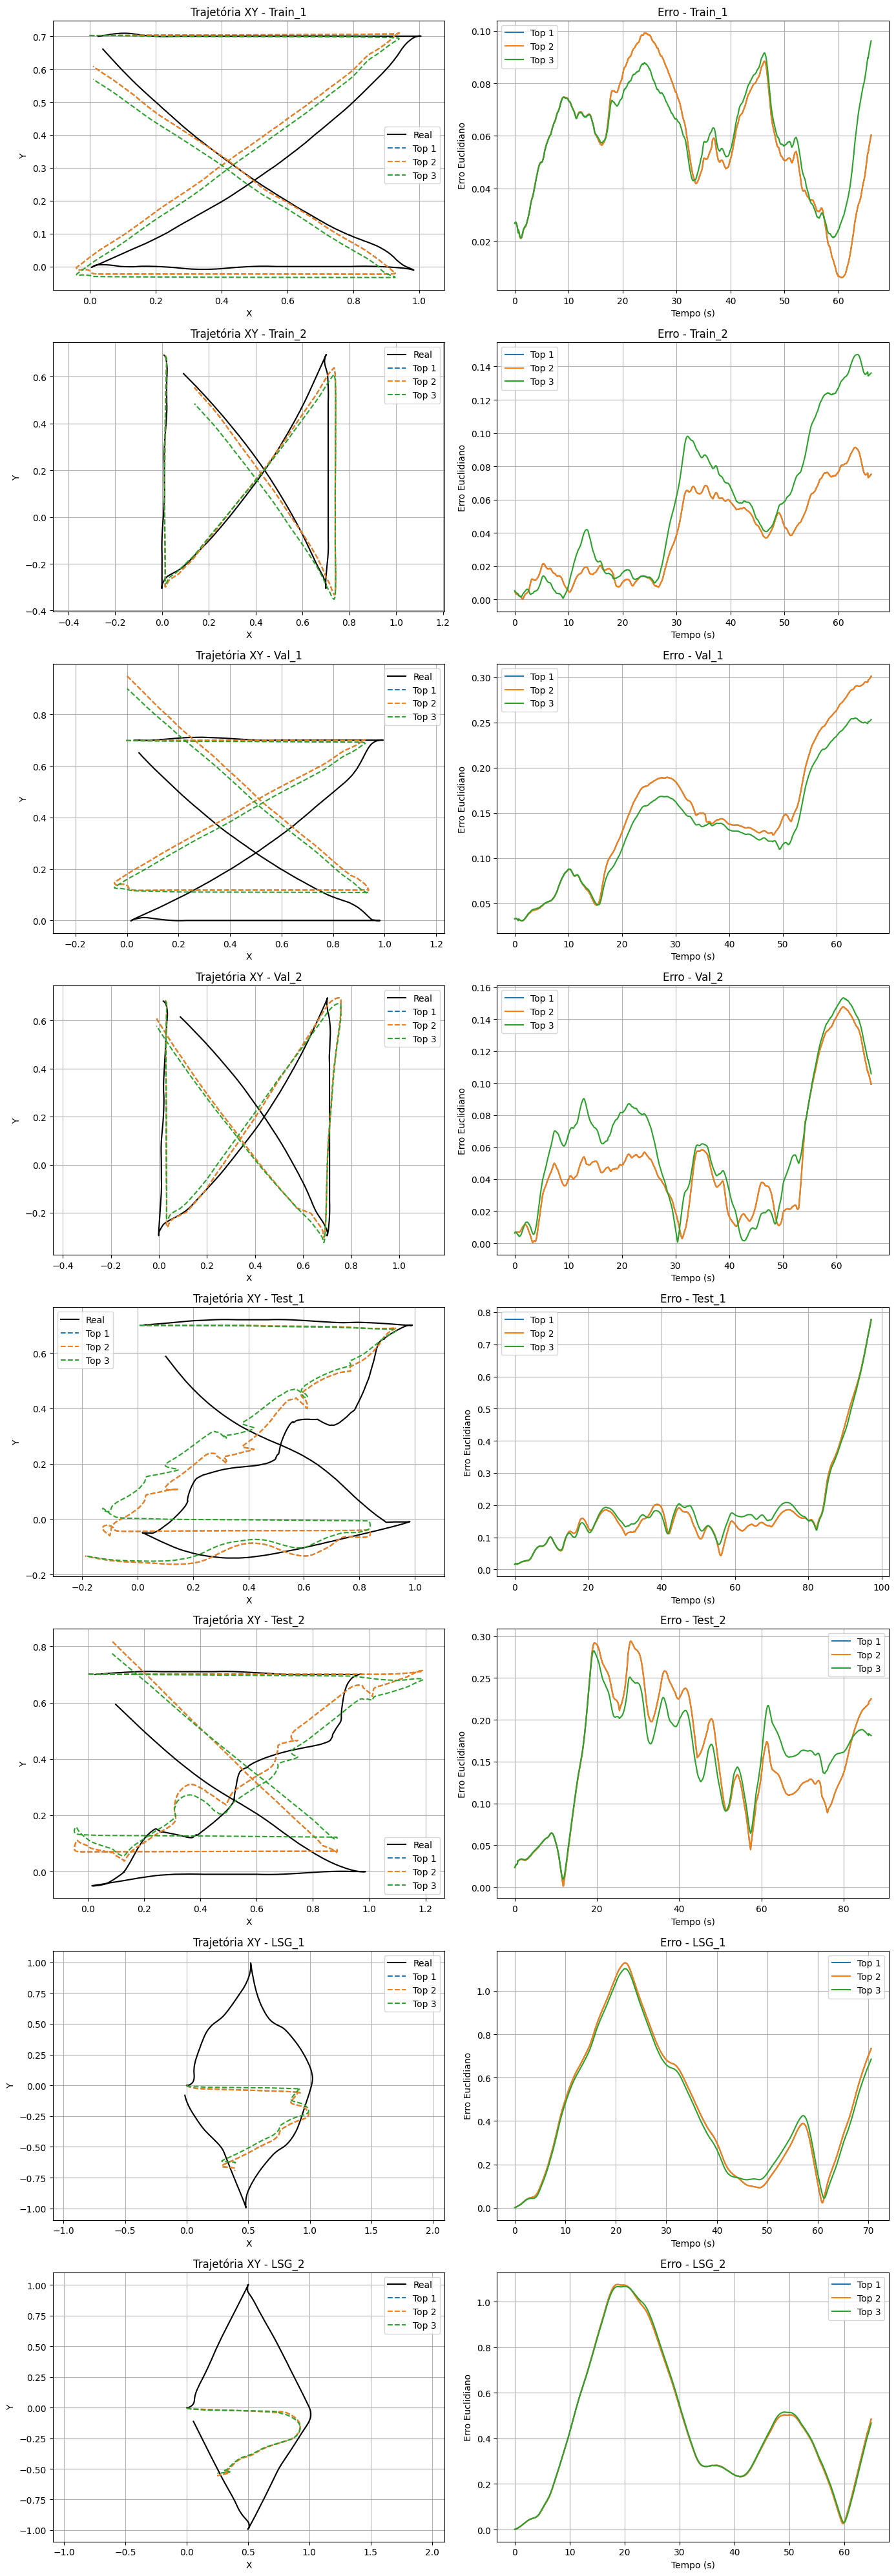

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

top3 = pd.read_excel("top3_combinacoes_gerais.xlsx")

n_rows = len(TITLES)

fig, axs = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))

# 🔹 garantir que axs sempre seja 2D
if n_rows == 1:
    axs = np.expand_dims(axs, axis=0)

for idx, title in enumerate(TITLES):

    print(f"Plotando: {title}")

    dfX = df_X_all[title]
    dfY = df_Y_all[title]

    X_real = dfX["X_real"].values
    Y_real = dfY["Y_real"].values

    ax_traj = axs[idx, 0]
    ax_erro = axs[idx, 1]

    # =========================
    # 🔹 Trajetória
    # =========================
    ax_traj.plot(X_real, Y_real, 'k-', label="Real")

    for i in range(len(top3)):
        row = top3.iloc[i]
        col_x = row["X_model"]
        col_y = row["Y_model"]

        X_pred = dfX[col_x].values
        Y_pred = dfY[col_y].values

        min_len = min(len(X_real), len(X_pred), len(Y_real), len(Y_pred))

        Xr = X_real[:min_len]
        Yr = Y_real[:min_len]
        Xp = X_pred[:min_len]
        Yp = Y_pred[:min_len]

        ax_traj.plot(Xp, Yp, '--', label=f"Top {i+1}")

        # =========================
        # 🔹 Erro
        # =========================
        tempo = np.arange(min_len) * 0.07
        erro = np.sqrt((Xr - Xp)**2 + (Yr - Yp)**2)

        ax_erro.plot(tempo, erro, label=f"Top {i+1}")

    ax_traj.set_title(f"Trajetória XY - {title}")
    ax_traj.set_xlabel("X")
    ax_traj.set_ylabel("Y")
    ax_traj.axis("equal")
    ax_traj.grid(True)
    ax_traj.legend()

    ax_erro.set_title(f"Erro - {title}")
    ax_erro.set_xlabel("Tempo (s)")
    ax_erro.set_ylabel("Erro Euclidiano")
    ax_erro.grid(True)
    ax_erro.legend()

plt.tight_layout()
plt.show()